In [1]:
# Import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
from google.colab import files

uploaded = files.upload()

Saving rounded_hours_student_scores.csv to rounded_hours_student_scores.csv


In [4]:
# Load the dataset

df = pd.read_csv("rounded_hours_student_scores.csv")

# Display first 5 rows
df.head()

,Hours,Scores
0,1.1,41
1,1.2,40
2,1.4,38
3,1.5,39
4,1.6,36


In [5]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 60
Number of columns: 2


In [7]:
print("Column names:")
print(df.columns.tolist())


Column names:
['Hours', 'Scores']


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Hours   60 non-null     float64
 1   Scores  60 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 1.1 KB


In [9]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
Hours     0
Scores    0
dtype: int64


In [10]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [11]:
df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (60, 2)


In [12]:
df.describe()

,Hours,Scores
count,60.000000,60.000000
mean,5.150000,46.433333
std,2.402365,5.699737
min,1.100000,36.000000
25%,3.150000,41.000000
50%,5.150000,47.000000
75%,7.150000,50.000000
max,9.200000,65.000000


In [13]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Missing values:
Hours     0
Scores    0
dtype: int64

Duplicate rows:
0


In [14]:
print(df.dtypes)

Hours     float64
Scores      int64
dtype: object


📊 Data Visualization

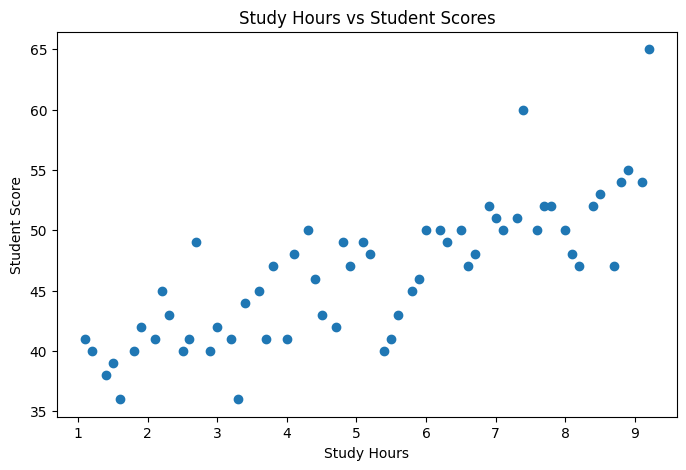

In [15]:
plt.figure(figsize=(8, 5))

plt.scatter(df["Hours"], df["Scores"])

plt.xlabel("Study Hours")
plt.ylabel("Student Score")
plt.title("Study Hours vs Student Scores")

plt.show()

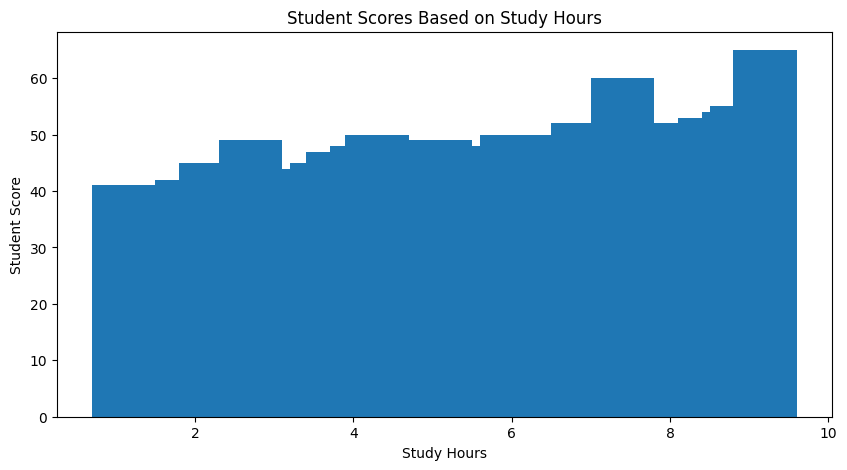

In [16]:
plt.figure(figsize=(10, 5))

plt.bar(df["Hours"], df["Scores"])

plt.xlabel("Study Hours")
plt.ylabel("Student Score")
plt.title("Student Scores Based on Study Hours")

plt.show()

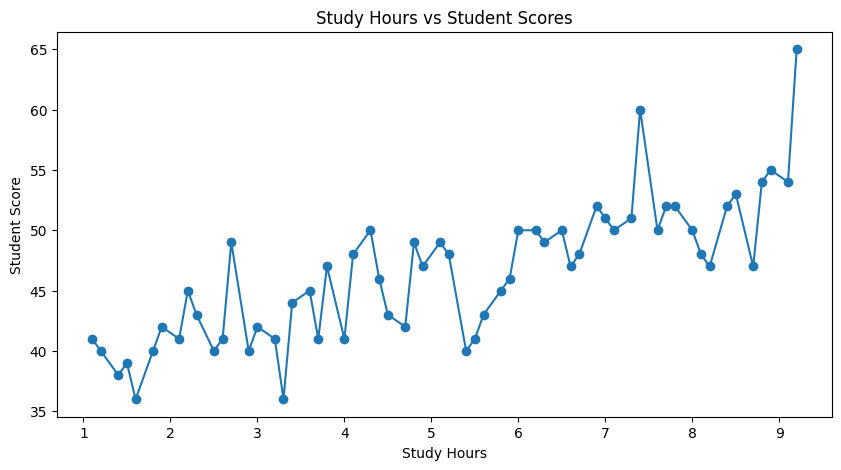

In [17]:
plt.figure(figsize=(10, 5))

plt.plot(df["Hours"], df["Scores"], marker="o")

plt.xlabel("Study Hours")
plt.ylabel("Student Score")
plt.title("Study Hours vs Student Scores")

plt.show()

📈 Correlation Analysis

In [18]:
correlation = df["Hours"].corr(df["Scores"])

print("Correlation between Study Hours and Scores:", correlation)

Correlation between Study Hours and Scores: 0.7983878726756597


In [19]:
correlation_matrix = df.corr()

print(correlation_matrix)

           Hours    Scores
Hours   1.000000  0.798388
Scores  0.798388  1.000000


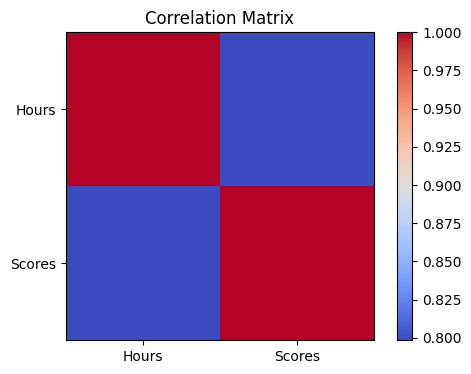

In [20]:
plt.figure(figsize=(6, 4))

plt.imshow(correlation_matrix, cmap="coolwarm")

plt.colorbar()

plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)

plt.title("Correlation Matrix")

plt.show()

🤖 Machine Learning

In [21]:
X = df[["Hours"]]
y = df["Scores"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   Hours
0    1.1
1    1.2
2    1.4
3    1.5
4    1.6

Target:
0    41
1    40
2    38
3    39
4    36
Name: Scores, dtype: int64


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (48, 1)
Testing data: (12, 1)


Linear Regression Model

In [23]:
model = LinearRegression()

print("Linear Regression model created successfully.")

Linear Regression model created successfully.


In [24]:
model.fit(X_train, y_train)

print("Model training completed successfully.")

Model training completed successfully.


In [25]:
slope = model.coef_[0]
intercept = model.intercept_

print("Slope:", slope)
print("Intercept:", intercept)

print("\nLinear Regression Equation:")
print(f"Score = {slope:.2f} × Hours + {intercept:.2f}")

Slope: 1.8742157088578226
Intercept: 36.46097067904956

Linear Regression Equation:
Score = 1.87 × Hours + 36.46


In [26]:
y_pred = model.predict(X_test)

print("Predicted scores:")
print(y_pred)

Predicted scores:
[38.52260796 39.83455895 47.70626493 50.14274535 41.89619623 52.3918042
 46.95657865 50.89243164 41.52135309 53.14149049 50.33016692 51.45469635]


In [27]:
comparison = pd.DataFrame({
    "Study Hours": X_test["Hours"].values,
    "Actual Score": y_test.values,
    "Predicted Score": y_pred
})

comparison

,Study Hours,Actual Score,Predicted Score
0,1.1,41,38.522608
1,1.8,40,39.834559
2,6.0,50,47.706265
3,7.3,51,50.142745
4,2.9,40,41.896196
5,8.5,53,52.391804
6,5.6,43,46.956579
7,7.7,52,50.892432
8,2.7,49,41.521353
9,8.9,55,53.141490


In [28]:
comparison_sorted = comparison.sort_values("Study Hours")

comparison_sorted

,Study Hours,Actual Score,Predicted Score
0,1.1,41,38.522608
1,1.8,40,39.834559
8,2.7,49,41.521353
4,2.9,40,41.896196
6,5.6,43,46.956579
2,6.0,50,47.706265
3,7.3,51,50.142745
10,7.4,60,50.330167
7,7.7,52,50.892432
11,8.0,50,51.454696


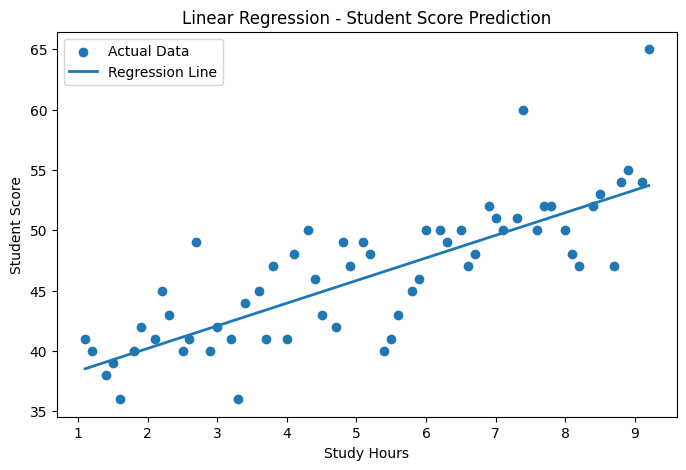

In [29]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Hours"],
    df["Scores"],
    label="Actual Data"
)

plt.plot(
    df["Hours"],
    model.predict(df[["Hours"]]),
    linewidth=2,
    label="Regression Line"
)

plt.xlabel("Study Hours")
plt.ylabel("Student Score")
plt.title("Linear Regression - Student Score Prediction")

plt.legend()

plt.show()

In [30]:
mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 2.8186706405470523


In [31]:
mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error:", mse)

Mean Squared Error: 15.667805255500062


In [32]:
r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.5809502309078735


In [33]:
print("MODEL EVALUATION")
print("-------------------------")

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R² Score: {r2:.4f}")

MODEL EVALUATION
-------------------------
Mean Absolute Error (MAE): 2.82
Mean Squared Error (MSE): 15.67
R² Score: 0.5810


In [34]:
hours = float(input("Enter the number of study hours: "))

prediction = model.predict([[hours]])

print("\nStudent Score Prediction")
print("-------------------------")
print("Study Hours:", hours)
print("Predicted Score:", round(prediction[0], 2))

Enter the number of study hours: 12

Student Score Prediction
-------------------------
Study Hours: 12.0
Predicted Score: 58.95


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [35]:
try:
    hours = float(input("Enter the number of study hours: "))

    if hours < 0:
        print("Study hours cannot be negative.")

    else:
        prediction = model.predict([[hours]])

        print("\n==============================")
        print("   STUDENT SCORE PREDICTION")
        print("==============================")
        print(f"Study Hours     : {hours}")
        print(f"Predicted Score : {prediction[0]:.2f}")
        print("==============================")

except ValueError:
    print("Please enter a valid number.")

Enter the number of study hours: 12

   STUDENT SCORE PREDICTION
Study Hours     : 12.0
Predicted Score : 58.95


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [36]:
print("FINAL PROJECT SUMMARY")
print("==============================")

print(f"Number of records       : {len(df)}")
print(f"Training records        : {len(X_train)}")
print(f"Testing records         : {len(X_test)}")
print(f"Correlation             : {correlation:.4f}")
print(f"MAE                     : {mae:.4f}")
print(f"MSE                     : {mse:.4f}")
print(f"R² Score                : {r2:.4f}")
print(f"Slope                   : {slope:.4f}")
print(f"Intercept               : {intercept:.4f}")

FINAL PROJECT SUMMARY
Number of records       : 60
Training records        : 48
Testing records         : 12
Correlation             : 0.7984
MAE                     : 2.8187
MSE                     : 15.6678
R² Score                : 0.5810
Slope                   : 1.8742
Intercept               : 36.4610


UI

In [37]:
!pip install -q streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 78.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 75.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.6/73.6 kB 3.9 MB/s eta 0:00:00


In [38]:
%%writefile app.py

import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# ============================================================
# PAGE CONFIGURATION
# ============================================================

st.set_page_config(
    page_title="Student Score Predictor",
    page_icon="🎓",
    layout="wide"
)


# ============================================================
# LOAD DATASET
# ============================================================

@st.cache_data
def load_data():

    df = pd.read_csv("rounded_hours_student_scores.csv")

    return df


df = load_data()


# ============================================================
# TRAIN MACHINE LEARNING MODEL
# ============================================================

X = df[["Hours"]]
y = df["Scores"]

model = LinearRegression()

model.fit(X, y)

y_pred = model.predict(X)


# ============================================================
# MODEL EVALUATION
# ============================================================

mae = mean_absolute_error(y, y_pred)

mse = mean_squared_error(y, y_pred)

r2 = r2_score(y, y_pred)


# ============================================================
# TITLE
# ============================================================

st.title("🎓 Student Score Predictor")

st.write(
    "A Machine Learning application that predicts "
    "student scores based on study hours."
)

st.divider()


# ============================================================
# SIDEBAR
# ============================================================

st.sidebar.title("📌 Project Information")

st.sidebar.write(
    """
    **Machine Learning Algorithm**

    Linear Regression

    **Input**

    Study Hours

    **Output**

    Predicted Student Score
    """
)

st.sidebar.divider()

st.sidebar.subheader("Dataset Information")

st.sidebar.write(
    f"Number of Records: {len(df)}"
)

st.sidebar.write(
    f"Minimum Study Hours: {df['Hours'].min()}"
)

st.sidebar.write(
    f"Maximum Study Hours: {df['Hours'].max()}"
)


# ============================================================
# TABS
# ============================================================

tab1, tab2, tab3 = st.tabs(
    [
        "🔮 Prediction",
        "📊 Data Analysis",
        "🤖 Model Performance"
    ]
)


# ============================================================
# TAB 1 — PREDICTION
# ============================================================

with tab1:

    st.header("🔮 Predict Student Score")

    st.write(
        "Enter the number of hours a student studies "
        "to predict their expected score."
    )

    hours = st.slider(
        "Select Study Hours",
        min_value=0.0,
        max_value=24.0,
        value=5.0,
        step=0.1
    )

    st.write(
        f"### Selected Study Hours: **{hours} hours**"
    )

    if st.button(
        "🔮 Predict Score",
        use_container_width=True
    ):

        prediction = model.predict(
            np.array([[hours]])
        )[0]

        # Keep prediction between 0 and 100
        prediction = max(0, min(100, prediction))

        st.success(
            f"### Predicted Score: {prediction:.2f} / 100"
        )

        # Performance message

        if prediction >= 75:

            st.info(
                "🌟 Excellent expected performance!"
            )

        elif prediction >= 50:

            st.info(
                "👍 Good expected performance."
            )

        else:

            st.warning(
                "📚 The student may need additional "
                "study time."
            )


# ============================================================
# TAB 2 — DATA ANALYSIS
# ============================================================

with tab2:

    st.header("📊 Dataset Analysis")

    st.subheader("Dataset Preview")

    st.dataframe(
        df,
        use_container_width=True
    )

    st.subheader("📈 Study Hours vs Student Scores")

    fig, ax = plt.subplots(
        figsize=(10, 5)
    )

    ax.scatter(
        df["Hours"],
        df["Scores"],
        label="Actual Scores"
    )

    ax.plot(
        df["Hours"],
        y_pred,
        linewidth=2,
        label="Regression Line"
    )

    ax.set_xlabel(
        "Study Hours"
    )

    ax.set_ylabel(
        "Student Score"
    )

    ax.set_title(
        "Study Hours vs Student Scores"
    )

    ax.legend()

    st.pyplot(fig)

    st.subheader("📋 Statistical Summary")

    st.dataframe(
        df.describe(),
        use_container_width=True
    )

    st.subheader("🔗 Correlation")

    correlation = df["Hours"].corr(
        df["Scores"]
    )

    st.write(
        f"Correlation between Study Hours "
        f"and Scores: **{correlation:.4f}**"
    )


# ============================================================
# TAB 3 — MODEL PERFORMANCE
# ============================================================

with tab3:

    st.header("🤖 Model Performance")

    st.write(
        "The Linear Regression model is evaluated "
        "using MAE, MSE and R² Score."
    )

    col1, col2, col3 = st.columns(3)

    with col1:

        st.metric(
            "MAE",
            f"{mae:.2f}"
        )

    with col2:

        st.metric(
            "MSE",
            f"{mse:.2f}"
        )

    with col3:

        st.metric(
            "R² Score",
            f"{r2:.2f}"
        )

    st.divider()

    st.subheader("📐 Linear Regression Equation")

    st.write(
        f"**Score = {model.coef_[0]:.2f} × Hours "
        f"+ {model.intercept_:.2f}**"
    )

    st.subheader("📊 Actual vs Predicted Scores")

    comparison = pd.DataFrame(
        {
            "Study Hours": df["Hours"],
            "Actual Score": df["Scores"],
            "Predicted Score": y_pred
        }
    )

    st.dataframe(
        comparison,
        use_container_width=True
    )


# ============================================================
# FOOTER
# ============================================================

st.divider()

st.caption(
    "Student Score Prediction | "
    "Machine Learning Project | "
    "Linear Regression"
)

Writing app.py


In [39]:
import os

print(os.listdir())

['.config', 'app.py', 'rounded_hours_student_scores.csv', 'sample_data']


In [40]:
from pyngrok import ngrok

ngrok.set_auth_token("3ClETFicapHcd8EIgq1fVDzqVjy_7hRW4WdmVpLLWvF2NL2Dj")

In [41]:
!streamlit run app.py &>/content/streamlit.log &

In [42]:
from pyngrok import ngrok

public_url = ngrok.connect(8501)

print("Your Streamlit App:")
print(public_url)

Your Streamlit App:
NgrokTunnel: "https://tapered-diabetes-breeding.ngrok-free.dev" -> "http://localhost:8501"
